# Mubawab Rabat — Pipeline complet avec visualisation à chaque étape

Chaque étape du pipeline (chargement → nettoyage → modèle) est suivie d'une **visualisation 📊**
qui montre ce que l'étape a changé dans les données.

Colonnes finales : `Type, Localisation, Area, Rooms, Bedrooms, Bathrooms, Current_state, Age, city, Price`
**Objectif : R² > 0.8**

## Étape 1 — Imports et réglages graphiques

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

M = lambda x, _: f'{x/1e6:.0f}M'          # formatter d'axe en millions
RED, GREEN, BLUE, GREY = '#c0392b', '#27ae60', '#2980b9', '#95a5a6'
funnel = {}                               # nombre de lignes à chaque étape

## Étape 2 — Chargement des données brutes

In [2]:
df = pd.read_csv('mubawab_properties.csv')
df_raw = df.copy()            # copie brute pour comparer avant / après
funnel['Données brutes'] = len(df)
print("Shape initiale:", df.shape)
df.head()

Shape initiale: (1165, 20)


,id,url,title,price,location,type,area,rooms,bedrooms,bathrooms,description,property_state,jardin,piscine,cuisine_equiped,terrasse,garage,ascenseur,quartier,status
0,6357490,https://www.mubawab.ma/fr/a/6357490/luxueuse-v...,NaN,14000000.0,NaN,villa,550.0,6.0,5.0,4.0,NaN,Moins d'un an,Oui,Oui,Oui,Oui,Oui,Non,Souissi à\n\t\t\t\t\t\t\tRabat,success
1,6829872,https://www.mubawab.ma/fr/a/6829872/bel-appart...,NaN,1980000.0,NaN,appartement,107.0,3.0,2.0,1.0,NaN,NaN,Non,Non,Non,Oui,Non,Non,Agdal à\n\t\t\t\t\t\t\tRabat,success
2,6897023,https://www.mubawab.ma/fr/a/6897023/villa-comm...,NaN,8900000.0,NaN,villa,791.0,8.0,5.0,3.0,NaN,20-30 ans,Oui,Oui,Non,Oui,Non,Non,Riyad à\n\t\t\t\t\t\t\tRabat,success
3,6984102,https://www.mubawab.ma/fr/a/6984102/vente-pala...,NaN,120000000.0,NaN,NaN,4800.0,22.0,10.0,5.0,NaN,NaN,Non,Oui,Oui,Non,Oui,Oui,Souissi à\n\t\t\t\t\t\t\tRabat,success
4,7002092,https://www.mubawab.ma/fr/a/7002092/vente-vill...,NaN,7500000.0,NaN,villa,622.0,8.0,4.0,4.0,NaN,NaN,Oui,Oui,Non,Non,Non,Non,Riyad à\n\t\t\t\t\t\t\tRabat,success


### 📊 Visualisation — étape 2 : qualité des données brutes

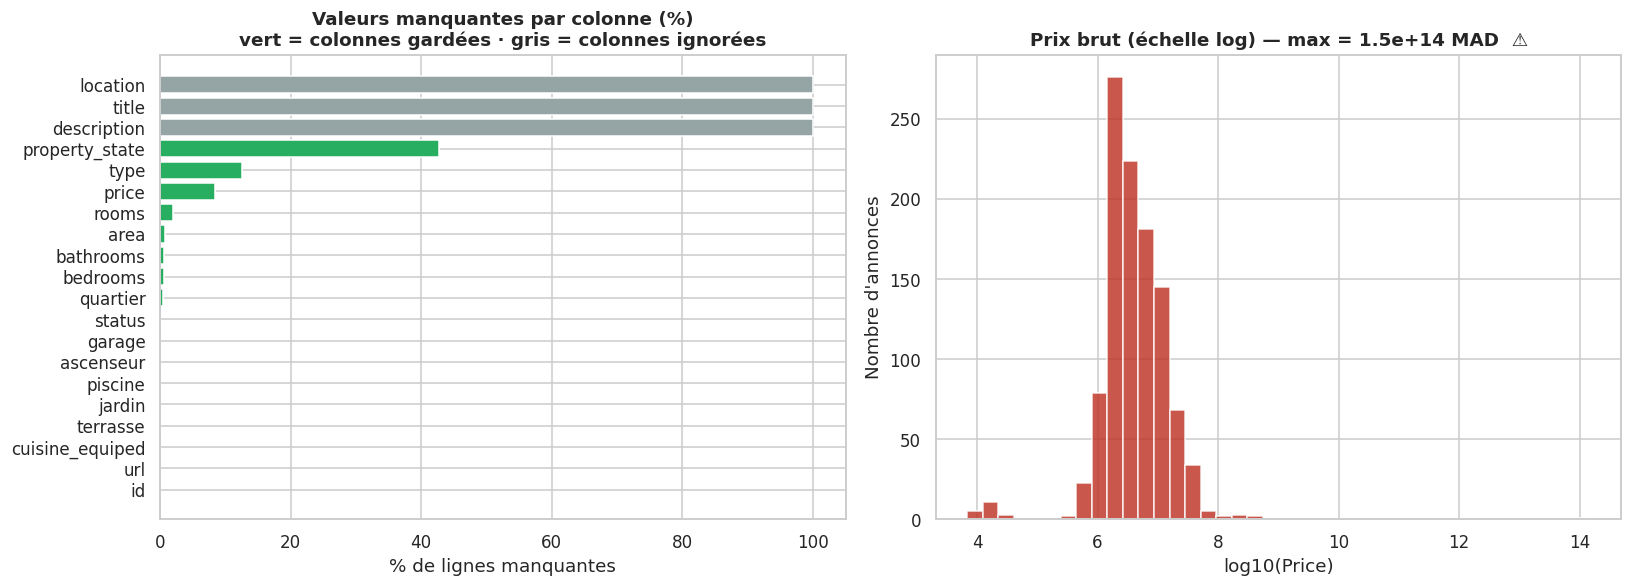

In [3]:
kept_cols = ['type','area','rooms','bedrooms','bathrooms','property_state','quartier','price']
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

miss = (df_raw.isna().mean() * 100).sort_values()
colors = [GREEN if c in kept_cols else GREY for c in miss.index]
axes[0].barh(miss.index, miss.values, color=colors)
axes[0].set_title('Valeurs manquantes par colonne (%)\nvert = colonnes gardées · gris = colonnes ignorées')
axes[0].set_xlabel('% de lignes manquantes')

p = pd.to_numeric(df_raw['price'], errors='coerce').dropna()
p = p[p > 0]
axes[1].hist(np.log10(p), bins=40, color=RED, alpha=.85)
axes[1].set_title(f'Prix brut (échelle log) — max = {p.max():.1e} MAD  ⚠️')
axes[1].set_xlabel('log10(Price)')
axes[1].set_ylabel("Nombre d'annonces")

plt.tight_layout(); plt.show()

## Étape 3 — Sélection des colonnes utiles
`title`, `location`, `description`, `status`, `url`... sont vides ou inutiles pour la prédiction du prix.

In [4]:
cols_needed = ['type','area','rooms','bedrooms','bathrooms','property_state','quartier','price']
df = df[cols_needed].copy()
df.isna().sum()

type              147
area                9
rooms              24
bedrooms            7
bathrooms           8
property_state    498
quartier            5
price              98
dtype: int64

### 📊 Visualisation — étape 3 : où sont les valeurs manquantes ?

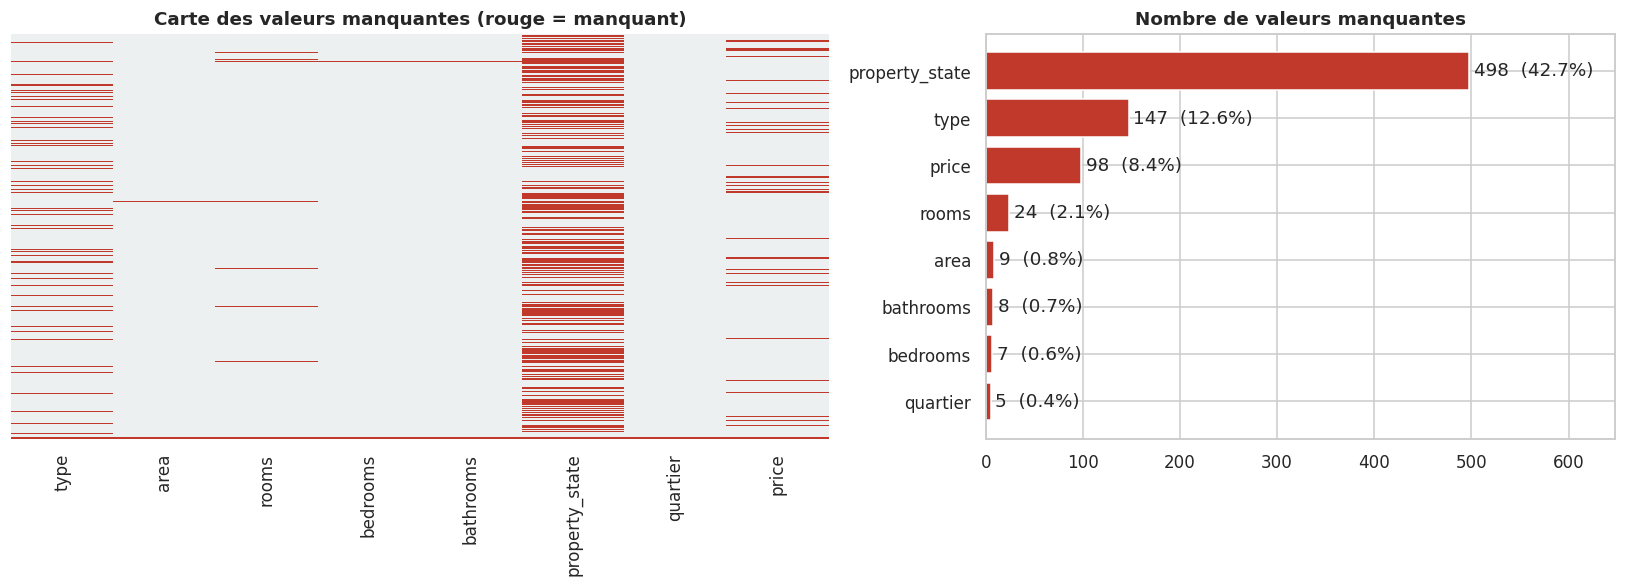

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={'width_ratios': [1.3, 1]})

sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap=['#ecf0f1', RED], ax=axes[0])
axes[0].set_title('Carte des valeurs manquantes (rouge = manquant)')

miss = df.isna().sum().sort_values()
axes[1].barh(miss.index, miss.values, color=RED)
for i, v in enumerate(miss.values):
    axes[1].text(v + 5, i, f'{v}  ({v/len(df)*100:.1f}%)', va='center')
axes[1].set_title('Nombre de valeurs manquantes')
axes[1].set_xlim(0, miss.max() * 1.3)

plt.tight_layout(); plt.show()

## Étape 4 — Extraction de `Localisation` et `city`
`quartier` contient des valeurs du type `"Souissi à\n\t\t\tRabat"` → on la découpe en quartier + ville.

In [6]:
def split_quartier(q):
    if pd.isna(q):
        return (np.nan, np.nan)
    q_clean = ' '.join(str(q).split())        # supprime \n \t multiples
    if ' à ' in q_clean:
        loc, city = q_clean.split(' à ', 1)
        return (loc.strip(), city.strip())
    return (q_clean.strip(), q_clean.strip())

df[['Localisation', 'city']] = df['quartier'].apply(lambda x: pd.Series(split_quartier(x)))
df.drop(columns=['quartier'], inplace=True)
df[['Localisation', 'city']].head()

,Localisation,city
0,Souissi,Rabat
1,Agdal,Rabat
2,Riyad,Rabat
3,Souissi,Rabat
4,Riyad,Rabat


### 📊 Visualisation — étape 4 : quartiers et villes extraits

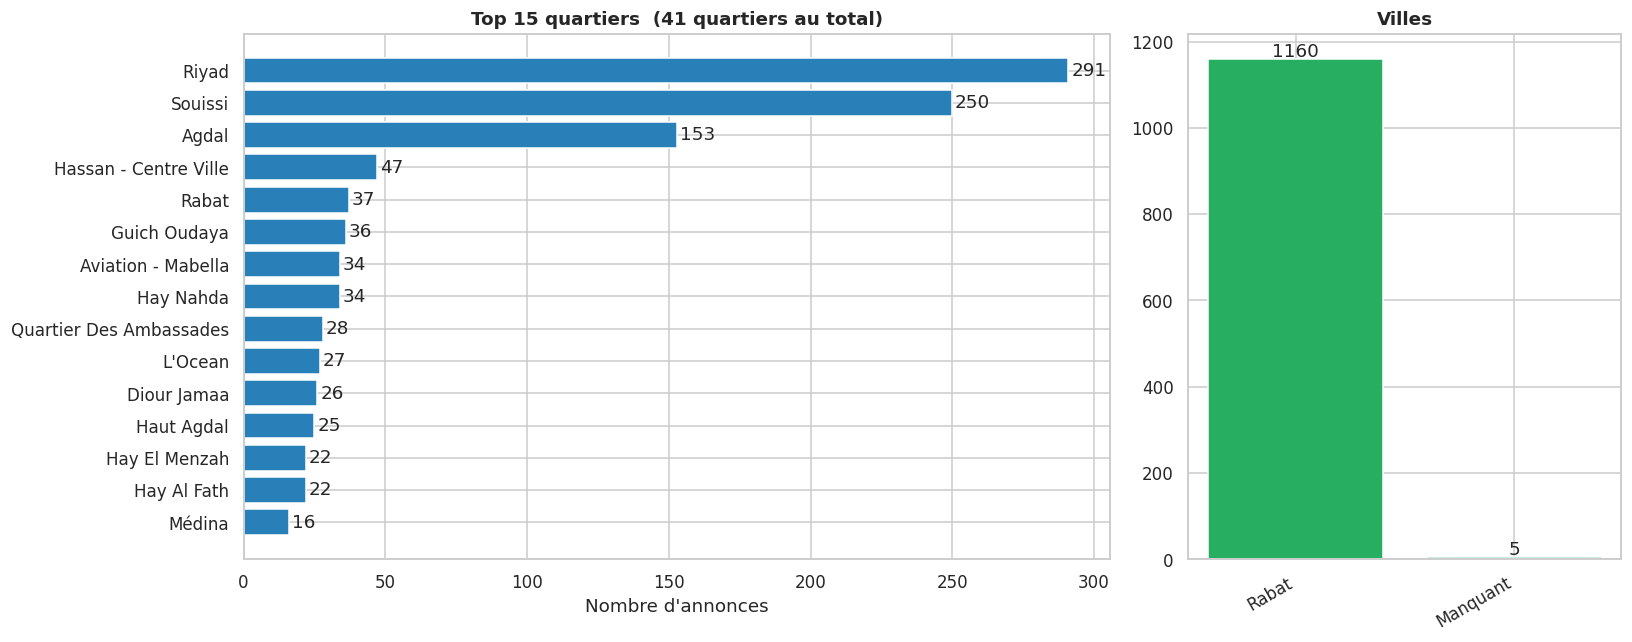

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})

vc = df['Localisation'].value_counts().head(15).sort_values()
axes[0].barh(vc.index, vc.values, color=BLUE)
for i, v in enumerate(vc.values):
    axes[0].text(v + 1, i, str(v), va='center')
axes[0].set_title(f"Top 15 quartiers  ({df['Localisation'].nunique()} quartiers au total)")
axes[0].set_xlabel("Nombre d'annonces")

vc = df['city'].fillna('Manquant').value_counts()
axes[1].bar(vc.index, vc.values, color=GREEN)
for i, v in enumerate(vc.values):
    axes[1].text(i, v + 5, str(v), ha='center')
axes[1].set_title('Villes')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout(); plt.show()

## Étape 5 — `property_state` → `Age` numérique
`property_state` est une tranche d'âge (ex: `10-20 ans`). On la convertit en années (milieu de la tranche)
et on renomme la colonne d'origine en `Current_state`.

In [8]:
age_map = {
    "Moins d'un an": 0.5,
    "1-5 ans": 3,
    "5-10 ans": 7.5,
    "10-20 ans": 15,
    "20-30 ans": 25,
    "30-50 ans": 40,
    "50-70 ans": 60,
    "70-100 ans": 85,
    "Plus de 100 ans": 110,
}
df['Age'] = df['property_state'].map(age_map)
df.rename(columns={'property_state': 'Current_state'}, inplace=True)
df[['Current_state', 'Age']].head()

,Current_state,Age
0,Moins d'un an,0.5
1,NaN,NaN
2,20-30 ans,25.0
3,NaN,NaN
4,NaN,NaN


### 📊 Visualisation — étape 5 : états du bien et âge estimé

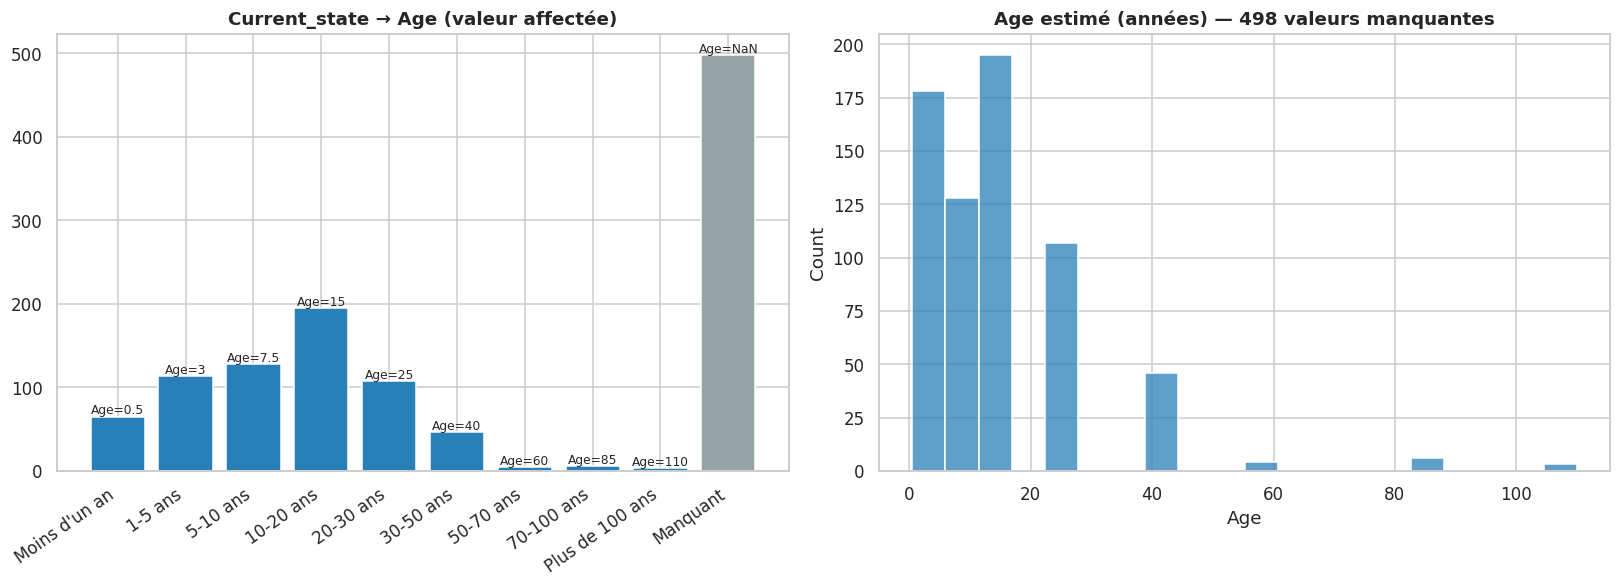

In [9]:
st = df['Current_state'].fillna('Manquant').value_counts()
order = [k for k in age_map if k in st.index] + [k for k in st.index if k not in age_map]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].bar(order, st[order].values, color=[BLUE if o in age_map else GREY for o in order])
for i, o in enumerate(order):
    axes[0].text(i, st[o] + 3, f'Age={age_map[o]}' if o in age_map else 'Age=NaN', ha='center', fontsize=8)
axes[0].set_title('Current_state → Age (valeur affectée)')
plt.setp(axes[0].get_xticklabels(), rotation=35, ha='right')

sns.histplot(df['Age'].dropna(), bins=20, color=BLUE, ax=axes[1])
axes[1].set_title(f"Age estimé (années) — {df['Age'].isna().sum()} valeurs manquantes")
axes[1].set_xlabel('Age')

plt.tight_layout(); plt.show()

## Étape 6 — Renommage final des colonnes

In [10]:
df.rename(columns={
    'type': 'Type', 'area': 'Area', 'rooms': 'Rooms',
    'bedrooms': 'Bedrooms', 'bathrooms': 'Bathrooms', 'price': 'Price'
}, inplace=True)

df = df[['Type', 'Localisation', 'Area', 'Rooms', 'Bedrooms', 'Bathrooms',
         'Current_state', 'Age', 'city', 'Price']]
df.head()

,Type,Localisation,Area,Rooms,Bedrooms,Bathrooms,Current_state,Age,city,Price
0,villa,Souissi,550.0,6.0,5.0,4.0,Moins d'un an,0.5,Rabat,14000000.0
1,appartement,Agdal,107.0,3.0,2.0,1.0,NaN,NaN,Rabat,1980000.0
2,villa,Riyad,791.0,8.0,5.0,3.0,20-30 ans,25.0,Rabat,8900000.0
3,NaN,Souissi,4800.0,22.0,10.0,5.0,NaN,NaN,Rabat,120000000.0
4,villa,Riyad,622.0,8.0,4.0,4.0,NaN,NaN,Rabat,7500000.0


### 📊 Visualisation — étape 6 : distribution de chaque colonne (avant tout filtrage)

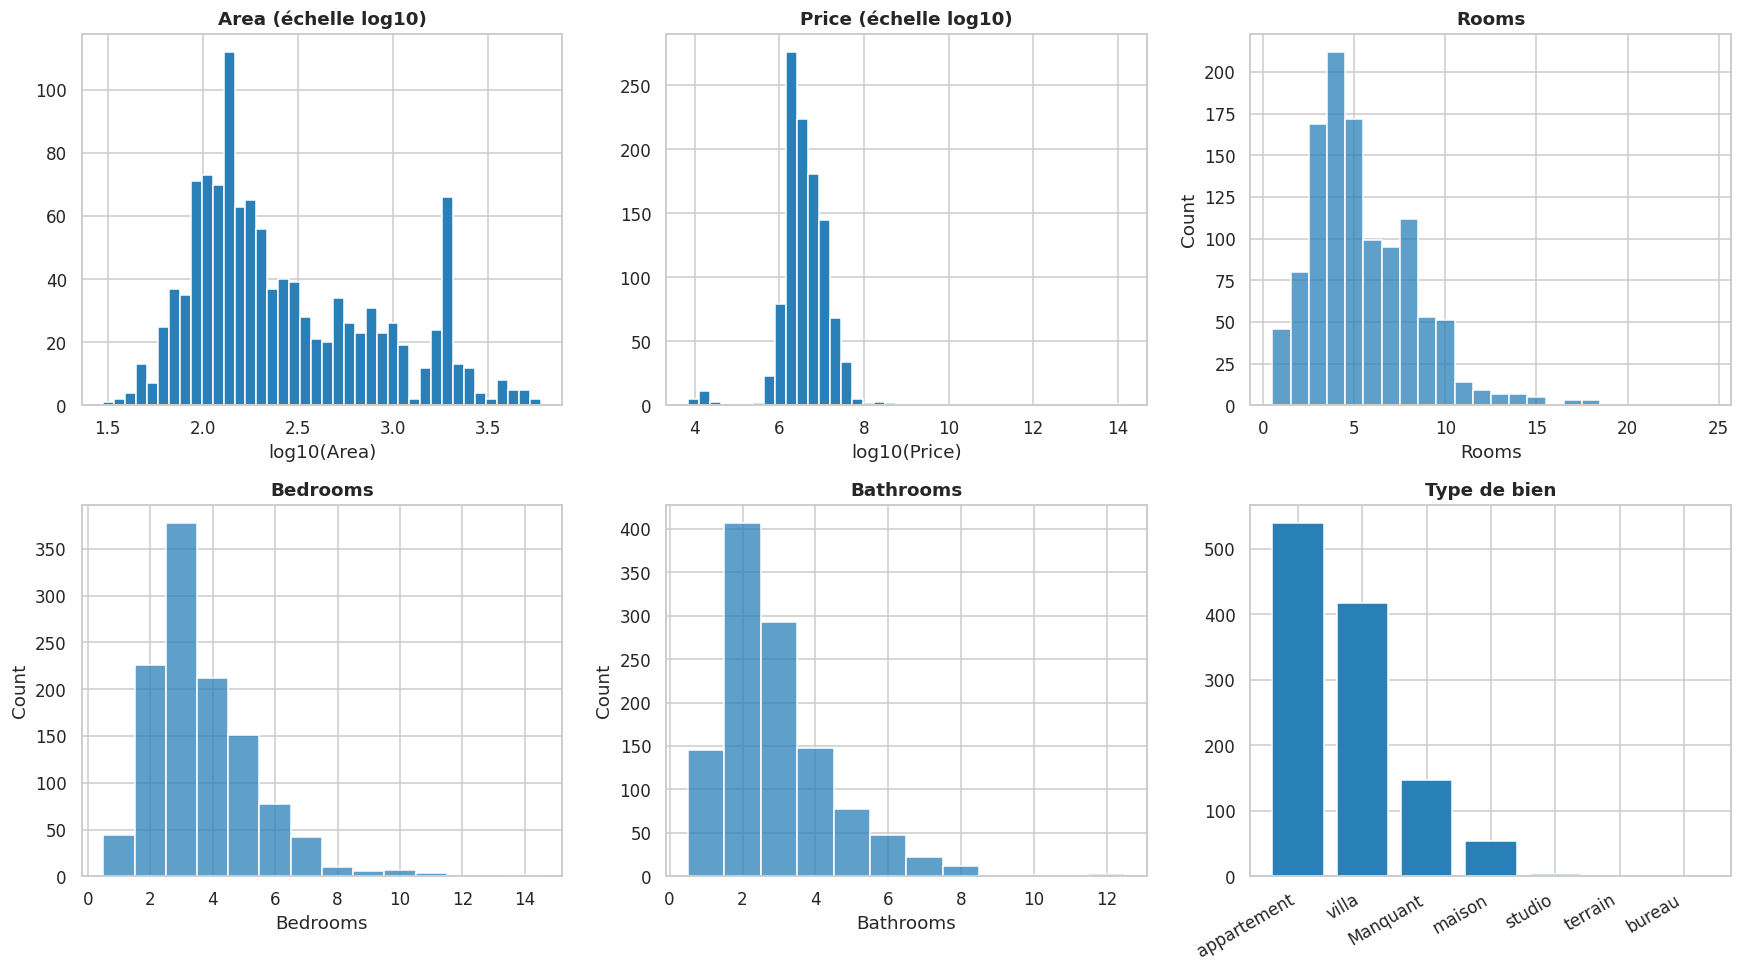

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat[:2], ['Area', 'Price']):
    s = pd.to_numeric(df[col], errors='coerce').dropna()
    s = s[s > 0]
    ax.hist(np.log10(s), bins=40, color=BLUE)
    ax.set_title(f'{col} (échelle log10)')
    ax.set_xlabel(f'log10({col})')

for ax, col in zip(axes.flat[2:5], ['Rooms', 'Bedrooms', 'Bathrooms']):
    sns.histplot(df[col].dropna(), discrete=True, color=BLUE, ax=ax)
    ax.set_title(f'{col}')

vc = df['Type'].fillna('Manquant').value_counts()
axes.flat[5].bar(vc.index, vc.values, color=BLUE)
axes.flat[5].set_title('Type de bien')
plt.setp(axes.flat[5].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout(); plt.show()

## Étape 7 — Suppression des valeurs aberrantes (Price / Area / pièces)
Certains prix sont absurdes (jusqu'à 1.5 × 10¹⁴ dh). On garde une plage réaliste :
Price ∈ [100 000 ; 60 000 000], Area ∈ [15 ; 3 000], pièces ≤ 20.

In [12]:
before7 = df.copy()                      # snapshot pour la visualisation

df = df[(df['Price'] >= 100_000) & (df['Price'] <= 60_000_000)]
df = df[(df['Area'] >= 15) & (df['Area'] <= 3000)]
for c in ['Rooms', 'Bedrooms', 'Bathrooms']:
    df = df[(df[c].isna()) | ((df[c] >= 0) & (df[c] <= 20))]

funnel['Après filtre outliers'] = len(df)
print("Après filtre outliers:", df.shape)

Après filtre outliers: (1015, 10)


### 📊 Visualisation — étape 7 : qu'est-ce qui a été supprimé ?

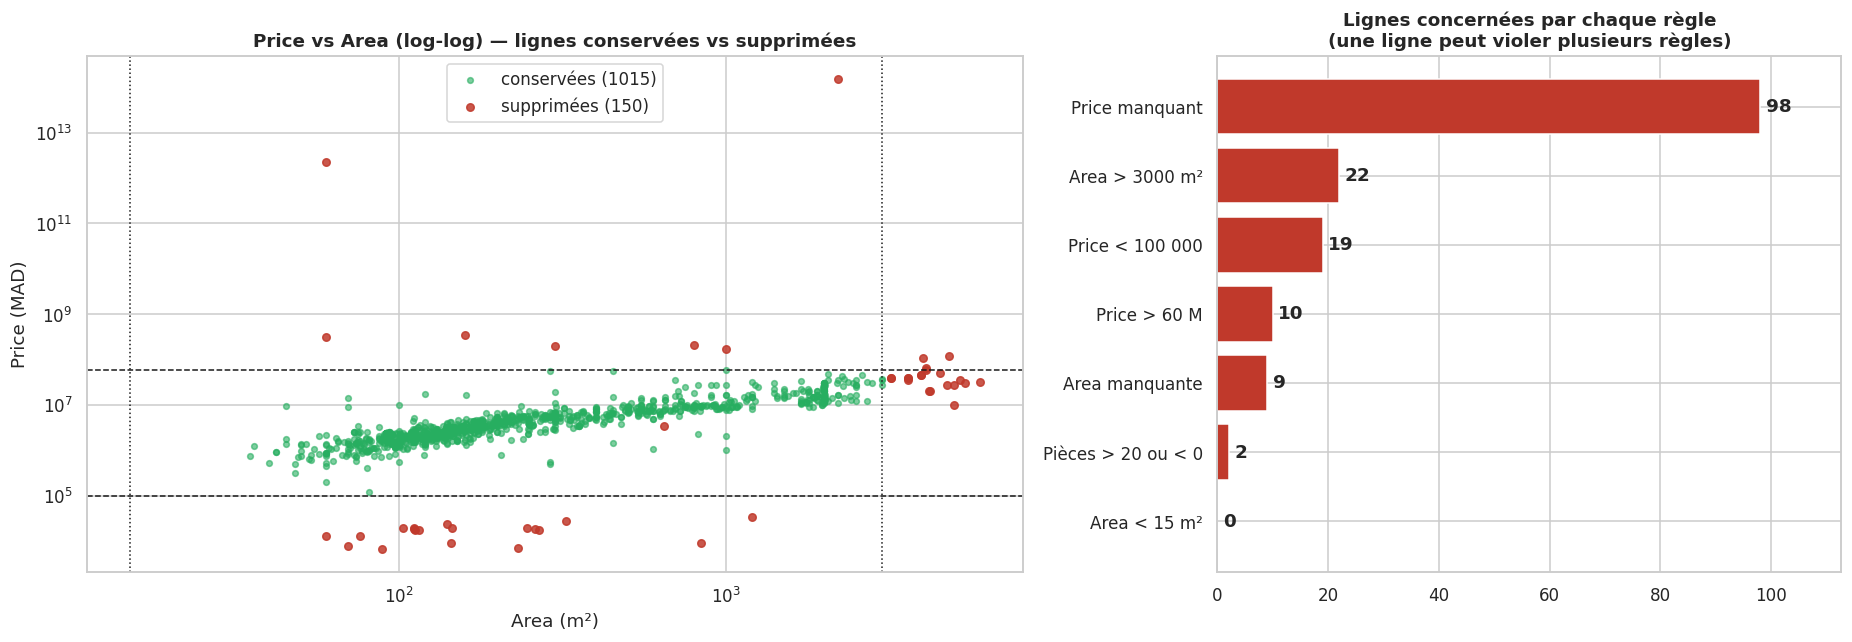

In [13]:
b = before7
kept7 = b.index.isin(df.index)

rules = pd.Series({
    'Price manquant':        b['Price'].isna().sum(),
    'Price < 100 000':       (b['Price'] < 100_000).sum(),
    'Price > 60 M':          (b['Price'] > 60_000_000).sum(),
    'Area manquante':        b['Area'].isna().sum(),
    'Area < 15 m²':          (b['Area'] < 15).sum(),
    'Area > 3000 m²':        (b['Area'] > 3000).sum(),
    'Pièces > 20 ou < 0':    sum(((b[c] > 20) | (b[c] < 0)).sum() for c in ['Rooms', 'Bedrooms', 'Bathrooms']),
}).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={'width_ratios': [1.5, 1]})

ok = b[kept7].dropna(subset=['Area', 'Price'])
ko = b[~kept7].dropna(subset=['Area', 'Price'])
ko = ko[(ko['Area'] > 0) & (ko['Price'] > 0)]
ax = axes[0]
ax.scatter(ok['Area'], ok['Price'], s=14, color=GREEN, alpha=.6, label=f'conservées ({kept7.sum()})')
ax.scatter(ko['Area'], ko['Price'], s=24, color=RED, alpha=.85, label=f'supprimées ({(~kept7).sum()})')
ax.set_xscale('log'); ax.set_yscale('log')
for yv in (100_000, 60_000_000): ax.axhline(yv, color='k', ls='--', lw=1)
for xv in (15, 3000):            ax.axvline(xv, color='k', ls=':', lw=1)
ax.set_title('Price vs Area (log-log) — lignes conservées vs supprimées')
ax.set_xlabel('Area (m²)'); ax.set_ylabel('Price (MAD)')
ax.legend()

axes[1].barh(rules.index, rules.values, color=RED)
for i, v in enumerate(rules.values):
    axes[1].text(v + 1, i, str(v), va='center', fontweight='bold')
axes[1].set_title("Lignes concernées par chaque règle\n(une ligne peut violer plusieurs règles)")
axes[1].set_xlim(0, rules.max() * 1.15)

plt.tight_layout(); plt.show()

## Étape 8 — Colonnes obligatoires : suppression des lignes incomplètes
Colonnes **obligatoires** : `Type, Area, Rooms, Bedrooms, Bathrooms, city, Price` → toute ligne avec un `NaN` est supprimée.
`Current_state`, `Age`, `Localisation` sont **optionnelles** → on les remplit (`Inconnu`, médiane, ville).
Ensuite on supprime les doublons.

In [14]:
essential = ['Type', 'Area', 'Rooms', 'Bedrooms', 'Bathrooms', 'city', 'Price']
optional  = ['Current_state', 'Age', 'Localisation']

miss_before8 = df[essential + optional].isna().sum().sort_values()
n_before8 = len(df)

df_clean = df.dropna(subset=essential).copy()
funnel['Après dropna (obligatoires)'] = len(df_clean)
print("Après dropna colonnes essentielles:", df_clean.shape)

df_clean['Current_state'] = df_clean['Current_state'].fillna('Inconnu')
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Localisation'] = df_clean['Localisation'].fillna(df_clean['city'])

df_clean.drop_duplicates(inplace=True)
funnel['Après doublons'] = len(df_clean)
print("Après suppression doublons:", df_clean.shape)

Après dropna colonnes essentielles: (880, 10)
Après suppression doublons: (857, 10)


### 📊 Visualisation — étape 8 : manquants obligatoires vs optionnels

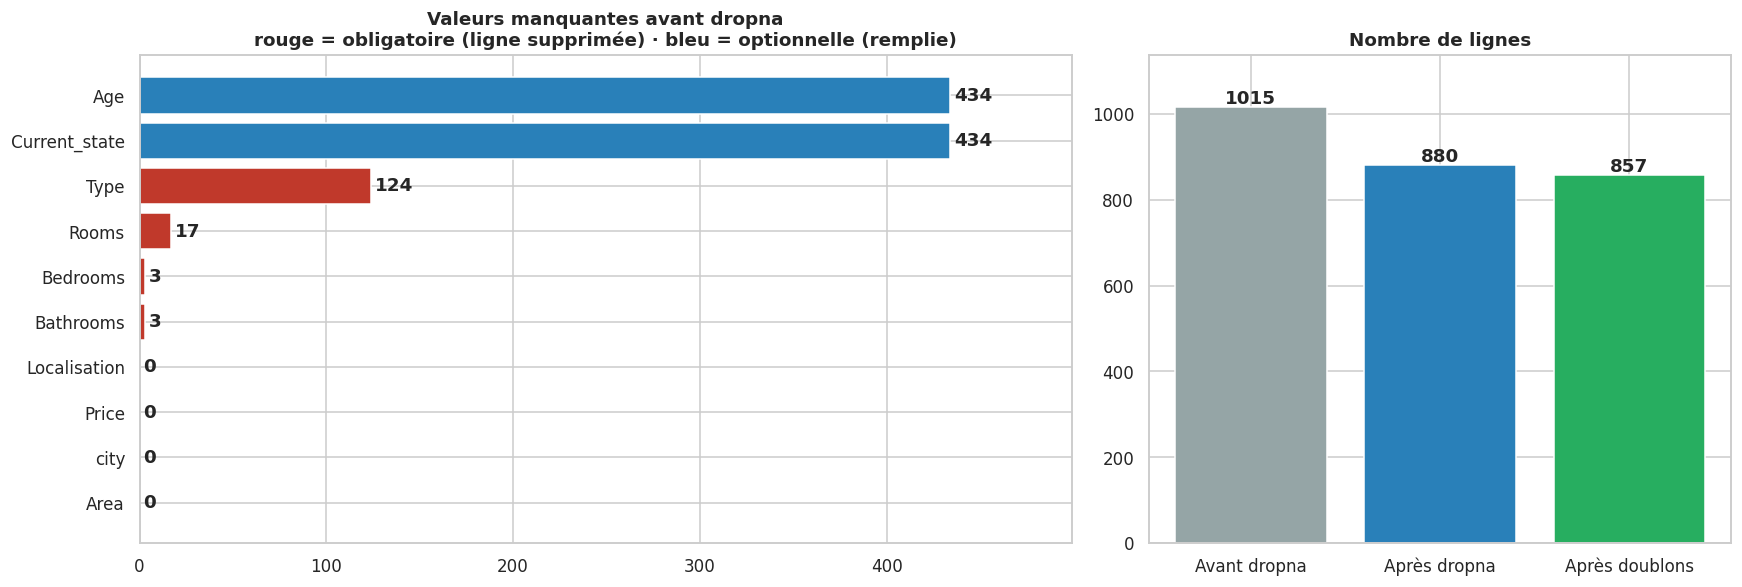

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={'width_ratios': [1.6, 1]})

cols_c = [RED if c in essential else BLUE for c in miss_before8.index]
axes[0].barh(miss_before8.index, miss_before8.values, color=cols_c)
for i, v in enumerate(miss_before8.values):
    axes[0].text(v + 2, i, str(v), va='center', fontweight='bold')
axes[0].set_title('Valeurs manquantes avant dropna\nrouge = obligatoire (ligne supprimée) · bleu = optionnelle (remplie)')
axes[0].set_xlim(0, miss_before8.max() * 1.15)

steps8 = pd.Series({'Avant dropna': n_before8,
                    'Après dropna': funnel['Après dropna (obligatoires)'],
                    'Après doublons': funnel['Après doublons']})
bars = axes[1].bar(steps8.index, steps8.values, color=[GREY, BLUE, GREEN])
for b_, v in zip(bars, steps8.values):
    axes[1].text(b_.get_x() + b_.get_width()/2, v + 8, str(v), ha='center', fontweight='bold')
axes[1].set_title('Nombre de lignes')
axes[1].set_ylim(0, steps8.max() * 1.12)

plt.tight_layout(); plt.show()

## Étape 9 — Erreurs de saisie : prix au m² aberrant (IQR par Type)
Même après le filtre global, certaines annonces ont un prix/m² incohérent pour leur type de bien
(ex: villa de 290 m² à 56 M dh). On filtre par IQR **par Type** sur `Price / Area`.

In [16]:
df_clean['ppm2'] = df_clean['Price'] / df_clean['Area']

bounds = df_clean.groupby('Type')['ppm2'].quantile([0.25, 0.75]).unstack()
bounds['iqr']  = bounds[0.75] - bounds[0.25]
bounds['low']  = bounds[0.25] - 0.5 * bounds['iqr']
bounds['high'] = bounds[0.75] + 0.5 * bounds['iqr']

low_map  = df_clean['Type'].map(bounds['low'])
high_map = df_clean['Type'].map(bounds['high'])
mask9 = (df_clean['ppm2'] >= low_map) & (df_clean['ppm2'] <= high_map)

before9 = df_clean.copy()
before9['statut'] = np.where(mask9, 'conservée', 'supprimée')

df_clean = df_clean[mask9].drop(columns=['ppm2'])
funnel['Après filtre prix/m²'] = len(df_clean)
print("Après filtre prix/m² (IQR par Type):", df_clean.shape)

Après filtre prix/m² (IQR par Type): (700, 10)


### 📊 Visualisation — étape 9 : les annonces à prix/m² aberrant

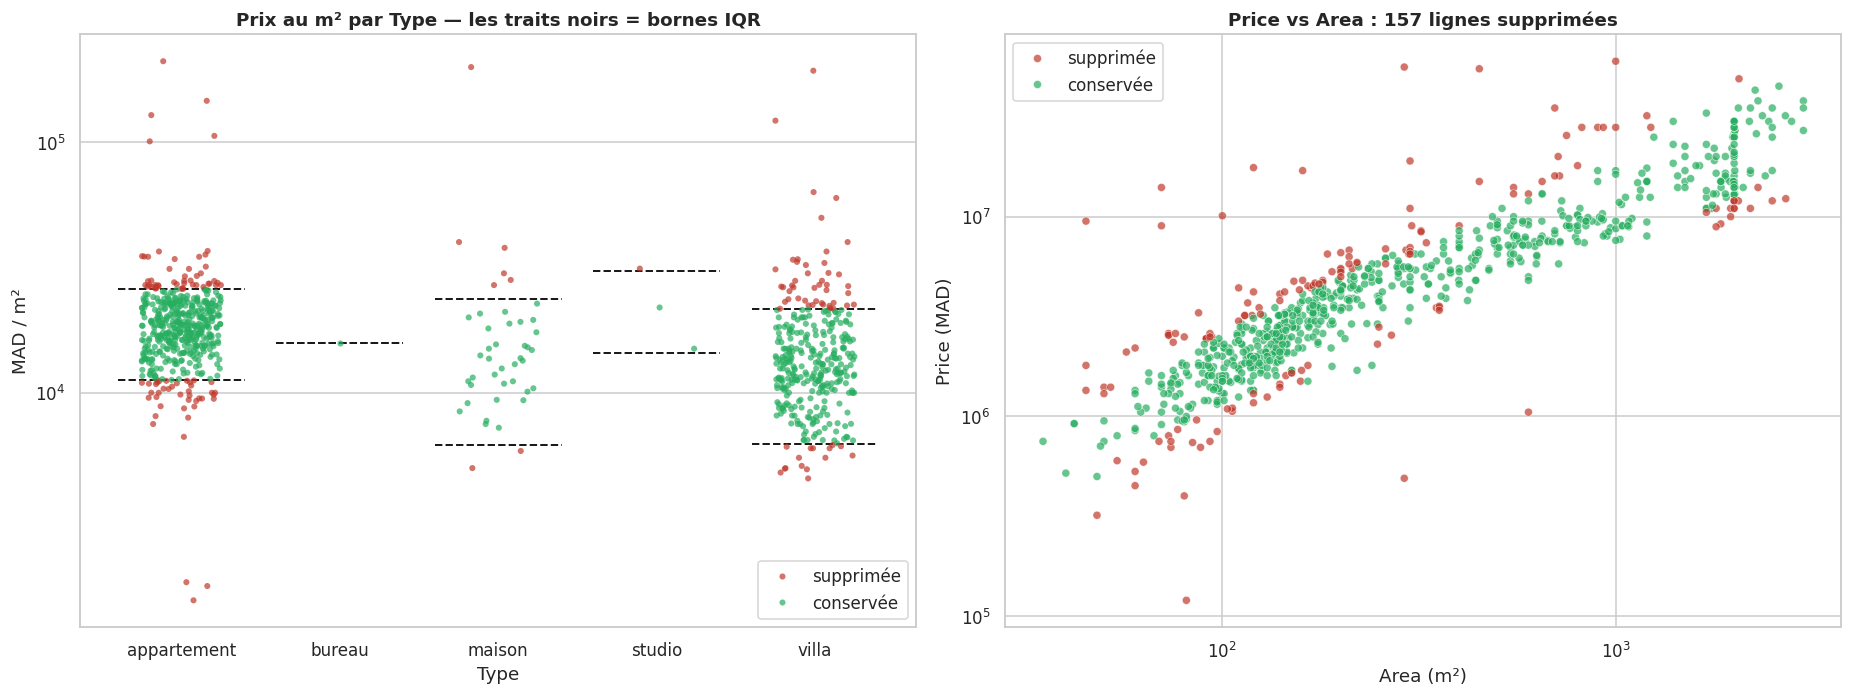

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
pal = {'conservée': GREEN, 'supprimée': RED}

types = list(bounds.index)
ax = axes[0]
sns.stripplot(data=before9, x='Type', y='ppm2', hue='statut', order=types, palette=pal,
              alpha=.7, size=4, jitter=.25, ax=ax)
for i, t in enumerate(types):
    ax.hlines([max(bounds.loc[t, 'low'], 1), bounds.loc[t, 'high']], i - .4, i + .4,
              colors='k', linestyles='--', lw=1.3)
ax.set_yscale('log')
ax.set_title('Prix au m² par Type — les traits noirs = bornes IQR')
ax.set_ylabel('MAD / m²')
ax.legend(title='')

ax = axes[1]
sns.scatterplot(data=before9, x='Area', y='Price', hue='statut', palette=pal, alpha=.7, s=28, ax=ax)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title(f"Price vs Area : {(before9['statut'] == 'supprimée').sum()} lignes supprimées")
ax.set_xlabel('Area (m²)'); ax.set_ylabel('Price (MAD)')
ax.legend(title='')

plt.tight_layout(); plt.show()

## Étape 10 — Sauvegarde du dataset nettoyé

In [18]:
df_clean.to_csv('mubawab_clean.csv', index=False)
df_clean.head()

,Type,Localisation,Area,Rooms,Bedrooms,Bathrooms,Current_state,Age,city,Price
1,appartement,Agdal,107.0,3.0,2.0,1.0,Inconnu,15.0,Rabat,1980000.0
2,villa,Riyad,791.0,8.0,5.0,3.0,20-30 ans,25.0,Rabat,8900000.0
4,villa,Riyad,622.0,8.0,4.0,4.0,Inconnu,15.0,Rabat,7500000.0
6,villa,Riyad,790.0,8.0,4.0,3.0,Inconnu,15.0,Rabat,7900000.0
7,villa,Riyad,310.0,7.0,5.0,4.0,Inconnu,15.0,Rabat,5400000.0


### 📊 Visualisation — étape 10 : bilan avant / après nettoyage

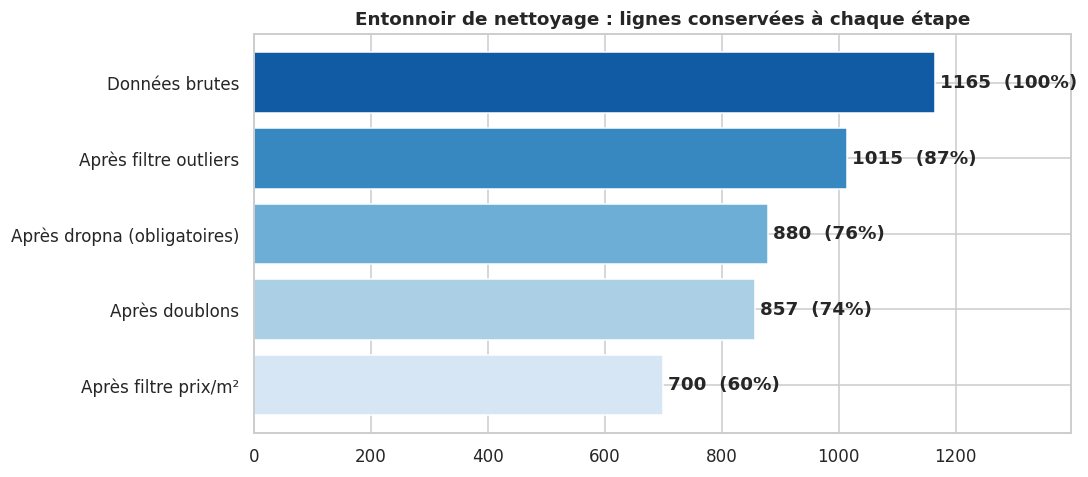

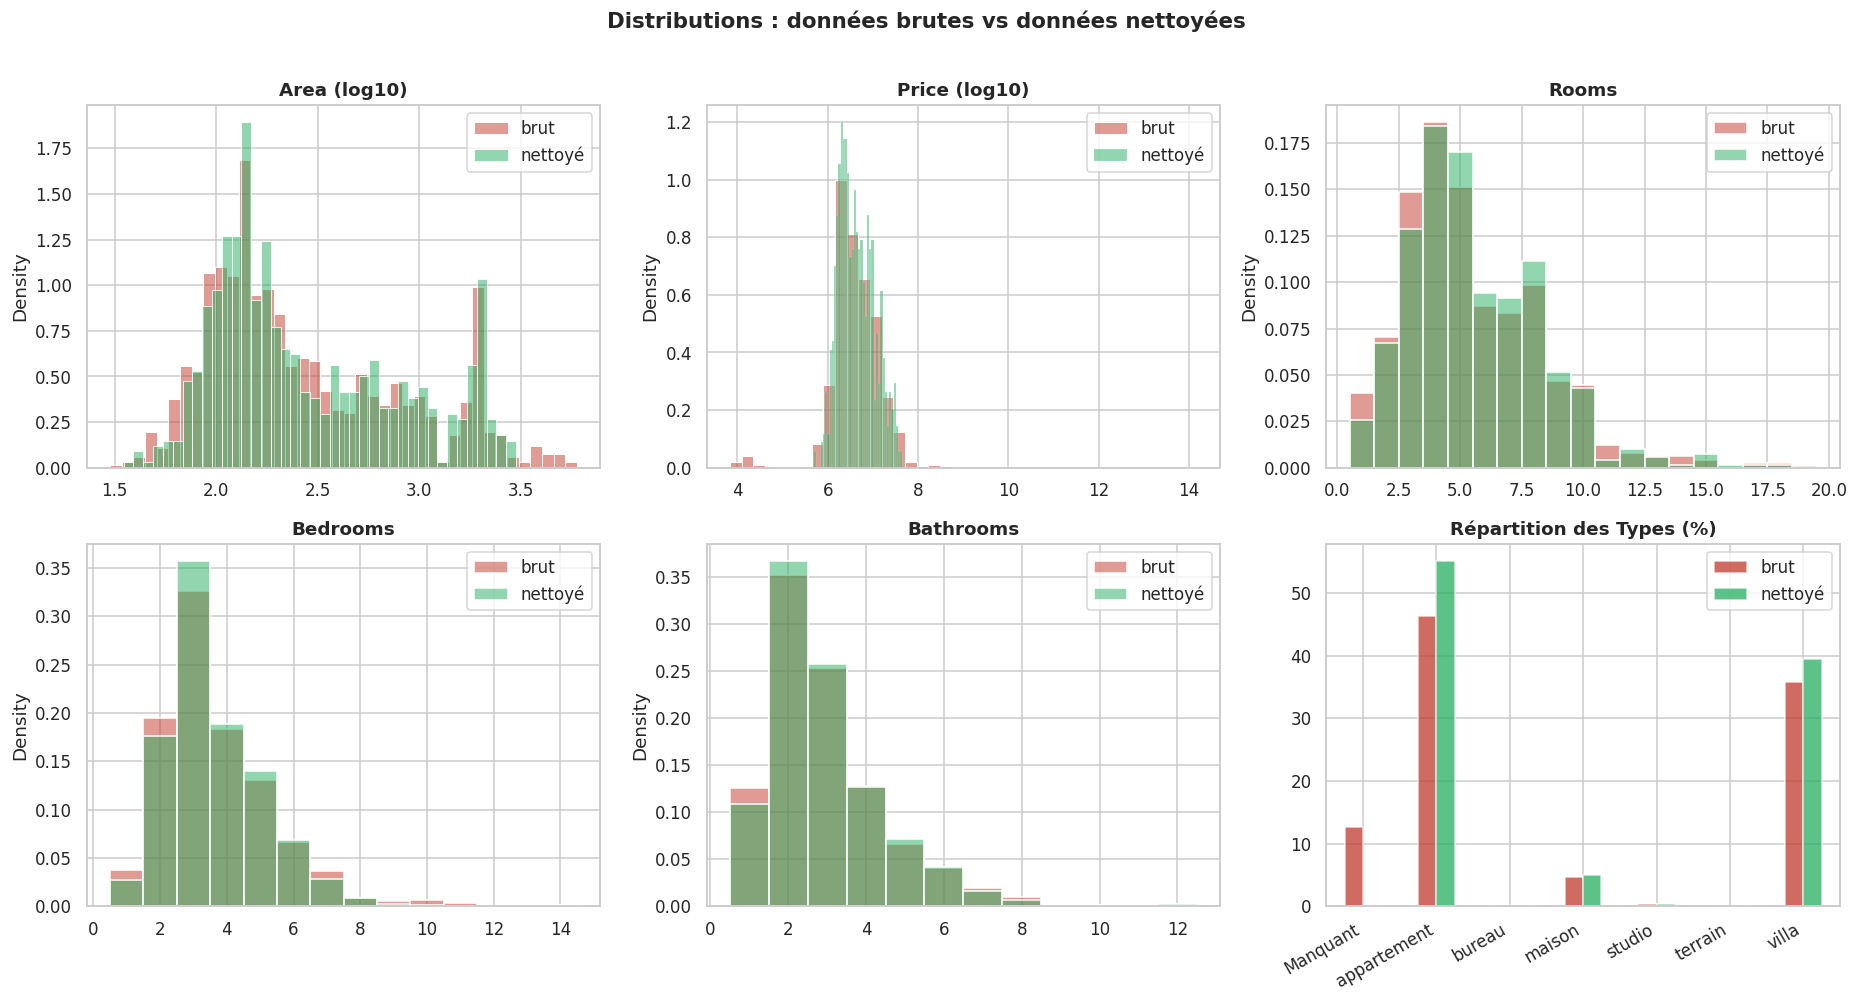

In [19]:
# (a) entonnoir : nombre de lignes à chaque étape
fs = pd.Series(funnel)
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(fs.index[::-1], fs.values[::-1], color=sns.color_palette('Blues_r', len(fs))[::-1])
for b_, v in zip(bars, fs.values[::-1]):
    ax.text(v + 8, b_.get_y() + b_.get_height()/2, f'{v}  ({v/fs.iloc[0]*100:.0f}%)', va='center', fontweight='bold')
ax.set_title("Entonnoir de nettoyage : lignes conservées à chaque étape")
ax.set_xlim(0, fs.max() * 1.2)
plt.tight_layout(); plt.show()

# (b) distributions brut vs nettoyé
def overlay(ax, col, log=False, discrete=False):
    a = pd.to_numeric(df_raw[col.lower()], errors='coerce').dropna()
    c = df_clean[col].dropna()
    if log:
        a, c = a[a > 0], c[c > 0]
        a, c = np.log10(a), np.log10(c)
    if discrete:
        a = a[a <= 20]
    kw = dict(stat='density', alpha=.5, ax=ax, common_norm=False)
    if discrete:
        sns.histplot(a, color=RED, label='brut', discrete=True, **kw)
        sns.histplot(c, color=GREEN, label='nettoyé', discrete=True, **kw)
    else:
        sns.histplot(a, color=RED, label='brut', bins=40, **kw)
        sns.histplot(c, color=GREEN, label='nettoyé', bins=40, **kw)
    ax.set_title(col + (' (log10)' if log else ''))
    ax.set_xlabel(''); ax.legend()

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
overlay(axes[0, 0], 'Area', log=True)
overlay(axes[0, 1], 'Price', log=True)
overlay(axes[0, 2], 'Rooms', discrete=True)
overlay(axes[1, 0], 'Bedrooms', discrete=True)
overlay(axes[1, 1], 'Bathrooms', discrete=True)

t_raw = df_raw['type'].fillna('Manquant').value_counts(normalize=True) * 100
t_cln = df_clean['Type'].value_counts(normalize=True) * 100
tt = pd.DataFrame({'brut': t_raw, 'nettoyé': t_cln}).fillna(0)
tt.plot(kind='bar', ax=axes[1, 2], color=[RED, GREEN], alpha=.75)
axes[1, 2].set_title('Répartition des Types (%)')
plt.setp(axes[1, 2].get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Distributions : données brutes vs données nettoyées', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## Étape 11 — Préparation des features
⚠️ Toutes les annonces concernent **Rabat** → `city` est constante : elle reste dans le CSV livrable mais est retirée des features.
Les `Localisation` rares (< 3 occurrences) sont regroupées sous `Autre` pour éviter un One-Hot trop creux.

In [20]:
X = df_clean[['Type', 'Localisation', 'Area', 'Rooms', 'Bedrooms', 'Bathrooms',
              'Current_state', 'Age']].copy()
y = df_clean['Price']

counts = X['Localisation'].value_counts()
rare = counts[counts < 3].index
X['Localisation'] = X['Localisation'].where(~X['Localisation'].isin(rare), 'Autre')

cat_cols = ['Type', 'Localisation', 'Current_state']
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
], remainder='passthrough')

print(f"Localisation : {counts.shape[0]} quartiers -> {X['Localisation'].nunique()} après regroupement")

Localisation : 33 quartiers -> 24 après regroupement


### 📊 Visualisation — étape 11 : regroupement des quartiers rares

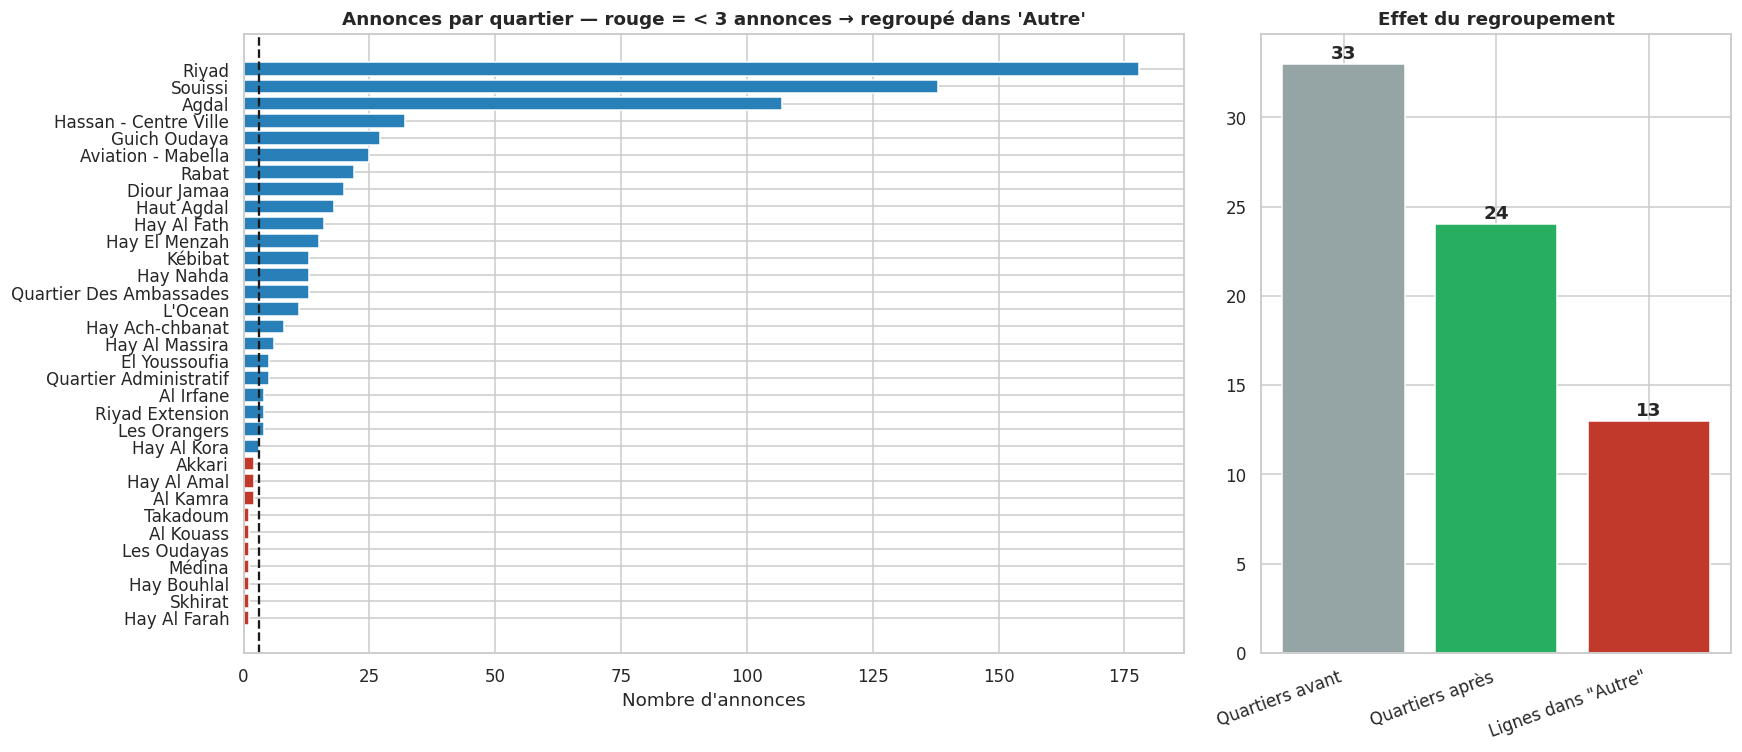

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2, 1]})

cs = counts.sort_values()
axes[0].barh(cs.index, cs.values, color=[RED if v < 3 else BLUE for v in cs.values])
axes[0].axvline(3, color='k', ls='--')
axes[0].set_title("Annonces par quartier — rouge = < 3 annonces → regroupé dans 'Autre'")
axes[0].set_xlabel("Nombre d'annonces")

info = pd.Series({'Quartiers avant': counts.shape[0],
                  'Quartiers après': X['Localisation'].nunique(),
                  'Lignes dans "Autre"': (X['Localisation'] == 'Autre').sum()})
bars = axes[1].bar(info.index, info.values, color=[GREY, GREEN, RED])
for b_, v in zip(bars, info.values):
    axes[1].text(b_.get_x() + b_.get_width()/2, v + .3, str(v), ha='center', fontweight='bold')
axes[1].set_title('Effet du regroupement')
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout(); plt.show()

## Étape 12 — Modèle : Random Forest (+ log du prix)
Le prix est très asymétrique → on entraîne sur `log1p(Price)` puis on inverse avec `expm1` pour prédire en MAD.

In [22]:
model = Pipeline([
    ('prep', preprocess),
    ('rf', RandomForestRegressor(n_estimators=500, min_samples_leaf=2,
                                 random_state=42, n_jobs=-1))
])

y_log = np.log1p(y)

X_train, X_test, y_train, y_test, y_train_raw, y_test_raw = train_test_split(
    X, y_log, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
pred = np.expm1(model.predict(X_test))

r2 = r2_score(y_test_raw, pred)
mae = mean_absolute_error(y_test_raw, pred)
print(f"R2 (test set, split 80/20) = {r2:.4f}")
print(f"MAE = {mae:,.0f} MAD")

R2 (test set, split 80/20) = 0.8651
MAE = 1,238,237 MAD


### 📊 Visualisation — étape 12 : prédictions sur le jeu de test

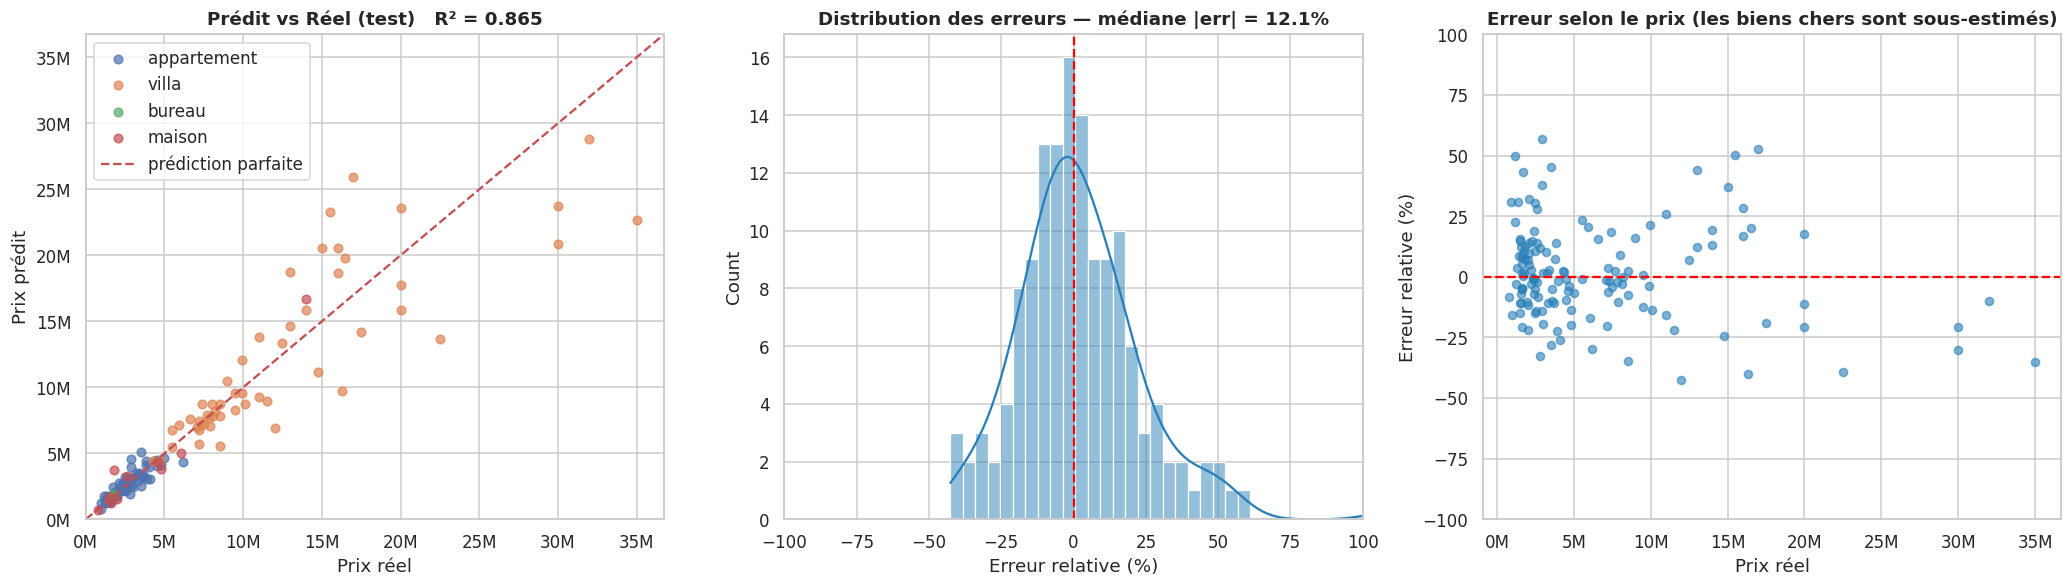

In [23]:
yt = y_test_raw.values
rel = (pred - yt) / yt * 100
typ = X_test['Type'].values

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

ax = axes[0]
for t in pd.unique(typ):
    m = typ == t
    ax.scatter(yt[m], pred[m], s=32, alpha=.7, label=t)
lim = [0, max(yt.max(), pred.max()) * 1.05]
ax.plot(lim, lim, 'r--', label='prédiction parfaite')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.xaxis.set_major_formatter(M); ax.yaxis.set_major_formatter(M)
ax.set_xlabel('Prix réel'); ax.set_ylabel('Prix prédit')
ax.set_title(f'Prédit vs Réel (test)   R² = {r2:.3f}')
ax.legend()

sns.histplot(rel, bins=35, kde=True, color=BLUE, ax=axes[1])
axes[1].axvline(0, color='red', ls='--')
axes[1].set_xlim(-100, 100)
axes[1].set_xlabel('Erreur relative (%)')
axes[1].set_title(f'Distribution des erreurs — médiane |err| = {np.median(np.abs(rel)):.1f}%')

axes[2].scatter(yt, rel, s=28, alpha=.6, color=BLUE)
axes[2].axhline(0, color='red', ls='--')
axes[2].xaxis.set_major_formatter(M)
axes[2].set_xlabel('Prix réel'); axes[2].set_ylabel('Erreur relative (%)')
axes[2].set_title('Erreur selon le prix (les biens chers sont sous-estimés)')
axes[2].set_ylim(-100, 100)

plt.tight_layout(); plt.show()

## Étape 13 — Validation croisée 5-fold
Avec un seul split 80/20, le R² peut dépendre de la chance. La CV vérifie que **R² > 0.8** est robuste.

In [24]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)
cv_scores = []
y_arr = y.values
oof = np.zeros(len(y_arr))               # prédictions out-of-fold
fold_id = np.zeros(len(y_arr), dtype=int)

for k, (tr_idx, te_idx) in enumerate(kf.split(X), start=1):
    model.fit(X.iloc[tr_idx], np.log1p(y_arr[tr_idx]))
    p = np.expm1(model.predict(X.iloc[te_idx]))
    oof[te_idx] = p
    fold_id[te_idx] = k
    cv_scores.append(r2_score(y_arr[te_idx], p))

print("R2 par fold:", [round(s, 3) for s in cv_scores])
print(f"R2 moyen (5-fold CV) = {np.mean(cv_scores):.4f}")

R2 par fold: [0.835, 0.817, 0.904, 0.871, 0.839]
R2 moyen (5-fold CV) = 0.8530


### 📊 Visualisation — étape 13 : stabilité du R² par fold

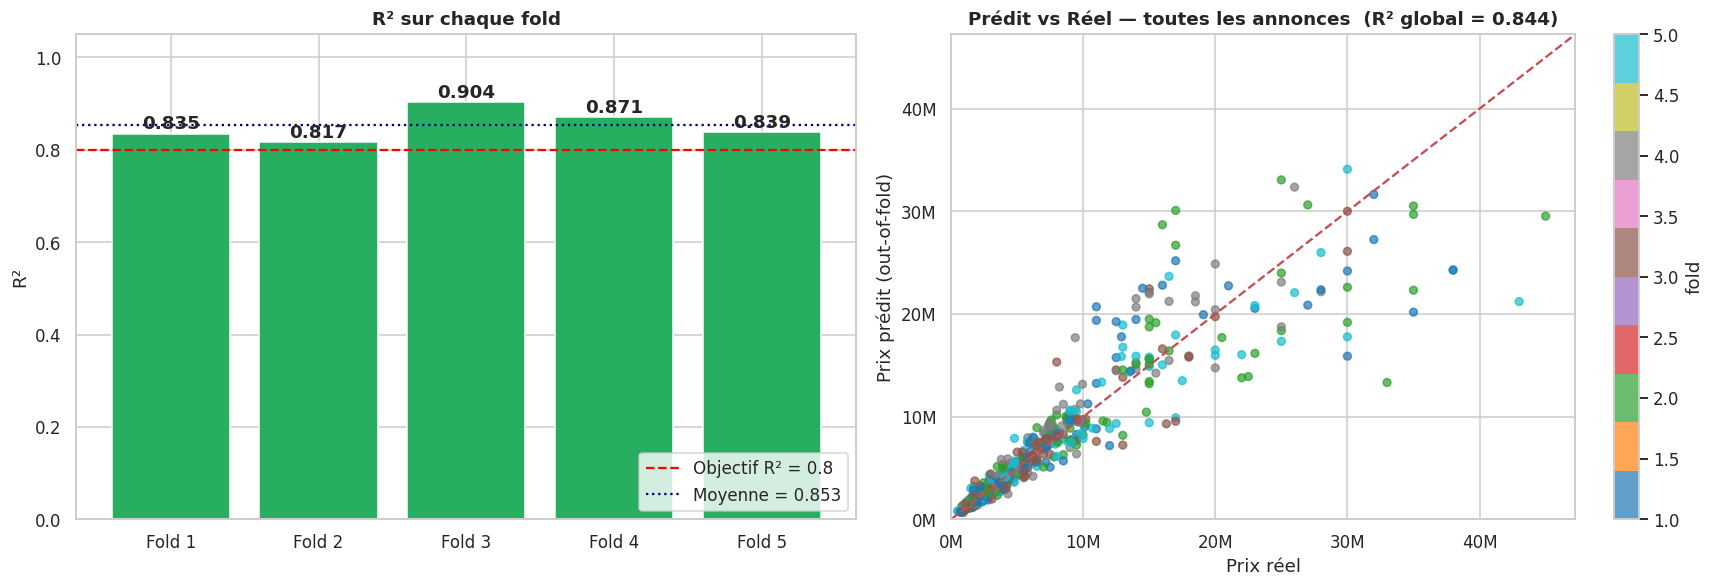

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

ax = axes[0]
bars = ax.bar([f'Fold {i+1}' for i in range(5)], cv_scores, color=GREEN)
ax.axhline(0.8, color='red', ls='--', label='Objectif R² = 0.8')
ax.axhline(np.mean(cv_scores), color='navy', ls=':', label=f'Moyenne = {np.mean(cv_scores):.3f}')
for b_, v in zip(bars, cv_scores):
    ax.text(b_.get_x() + b_.get_width()/2, v + .01, f'{v:.3f}', ha='center', fontweight='bold')
ax.set_ylim(0, 1.05); ax.set_ylabel('R²')
ax.set_title('R² sur chaque fold')
ax.legend(loc='lower right')

ax = axes[1]
sc = ax.scatter(y_arr, oof, c=fold_id, cmap='tab10', s=26, alpha=.7)
lim = [0, max(y_arr.max(), oof.max()) * 1.05]
ax.plot(lim, lim, 'r--')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.xaxis.set_major_formatter(M); ax.yaxis.set_major_formatter(M)
ax.set_xlabel('Prix réel'); ax.set_ylabel('Prix prédit (out-of-fold)')
ax.set_title(f'Prédit vs Réel — toutes les annonces  (R² global = {r2_score(y_arr, oof):.3f})')
plt.colorbar(sc, ax=ax, label='fold')

plt.tight_layout(); plt.show()

## Étape 14 — Entraînement final sur toutes les données + sauvegarde

In [26]:
model.fit(X, y_log)
joblib.dump(model, 'rf_price_model.joblib')
print("Modèle sauvegardé -> rf_price_model.joblib")

Modèle sauvegardé -> rf_price_model.joblib


## Étape 15 — Exemple de prédiction

In [28]:
example = pd.DataFrame([{
    'Type': 'appartement', 'Localisation': 'Agdal', 'Area': 110,
    'Rooms': 3, 'Bedrooms': 2, 'Bathrooms': 1,
    'Current_state': '5-10 ans', 'Age': 7.5,
}])

pred_price = np.expm1(model.predict(example))[0]
print(f"Prix estimé : {pred_price:,.0f} MAD")

Prix estimé : 1,885,593 MAD
